In [3]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel("E:/Atharv/IPL Project/new transformed data.xlsx")
df.head()

,match_id,date,innings,batting_team,bowling_team,player_of_match,match_won_by,win_outcome,toss_winner,toss_decision,venue,city,year,toss_advantage
0,335982,2008-04-18,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,"M Chinnaswamy Stadium, Bengaluru",Bangalore,2008,no
1,335983,2008-04-19,1,Chennai Super Kings,Kings XI Punjab,MEK Hussey,Chennai Super Kings,33 runs,Chennai Super Kings,bat,Punjab Cricket Association IS Bindra Stadium,Chandigarh,2008,yes
2,335984,2008-04-19,1,Rajasthan Royals,Delhi Daredevils,MF Maharoof,Delhi Daredevils,9 wickets,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi,2008,no
3,335985,2008-04-20,1,Mumbai Indians,Royal Challengers Bangalore,MV Boucher,Royal Challengers Bangalore,5 wickets,Mumbai Indians,bat,"Wankhede Stadium, Mumbai",Mumbai,2008,no
4,335986,2008-04-20,1,Deccan Chargers,Kolkata Knight Riders,DJ Hussey,Kolkata Knight Riders,5 wickets,Deccan Chargers,bat,"Eden Gardens, Kolkata",Kolkata,2008,no


In [21]:
df.shape #rows,columns
df.columns # column names
df.info() # data types
df.isnull().sum() # missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   match_id         1169 non-null   int64         
 1   date             1169 non-null   datetime64[ns]
 2   innings          1169 non-null   int64         
 3   batting_team     1169 non-null   object        
 4   bowling_team     1169 non-null   object        
 5   player_of_match  1169 non-null   object        
 6   match_won_by     1169 non-null   object        
 7   win_outcome      1169 non-null   object        
 8   toss_winner      1169 non-null   object        
 9   toss_decision    1169 non-null   object        
 10  venue            1169 non-null   object        
 11  city             1169 non-null   object        
 12  year             1169 non-null   int64         
 13  toss_advantage   1169 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1

match_id           0
date               0
innings            0
batting_team       0
bowling_team       0
player_of_match    0
match_won_by       0
win_outcome        0
toss_winner        0
toss_decision      0
venue              0
city               0
year               0
toss_advantage     0
dtype: int64

In [20]:
df['win_outcome'].fillna("tie/no result",inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_19756\2779433465.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['win_outcome'].fillna("tie/no result",inplace=True)


In [4]:
# top 5 winning teams
df["match_won_by"].value_counts().head(5)

match_won_by
Mumbai Indians                 151
Chennai Super Kings            142
Kolkata Knight Riders          135
Royal Challengers Bangalore    114
Rajasthan Royals               114
Name: count, dtype: int64

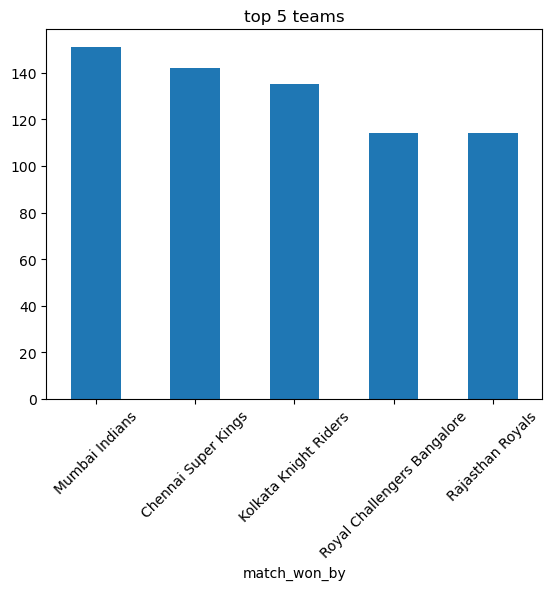

In [29]:
# plotting
df["match_won_by"].value_counts().head(5).plot(kind="bar")
plt.title("top 5 teams")
plt.xticks(rotation=45)
plt.show()

1.Mumbai Indians has won the maximum no of matches

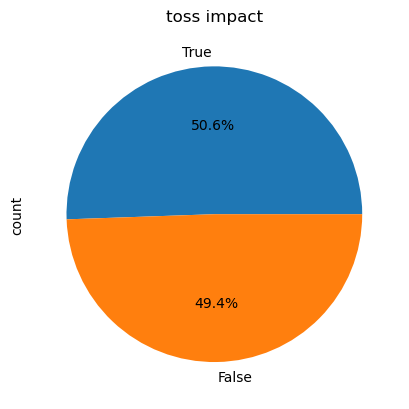

In [9]:
# toss winner vs match winner
(df["toss_winner"]==df["match_won_by"]).value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("toss impact")
plt.show()

2.toss has minimal impact on the final match outcome

In [10]:
# top 5 most played venues
df['venue'].value_counts().head(5)

venue
Wankhede Stadium, Mumbai                                125
Eden Gardens, Kolkata                                   100
M Chinnaswamy Stadium, Bengaluru                         99
MA Chidambaram Stadium, Chepauk, Chennai                 91
Rajiv Gandhi International Stadium, Uppal, Hyderabad     83
Name: count, dtype: int64

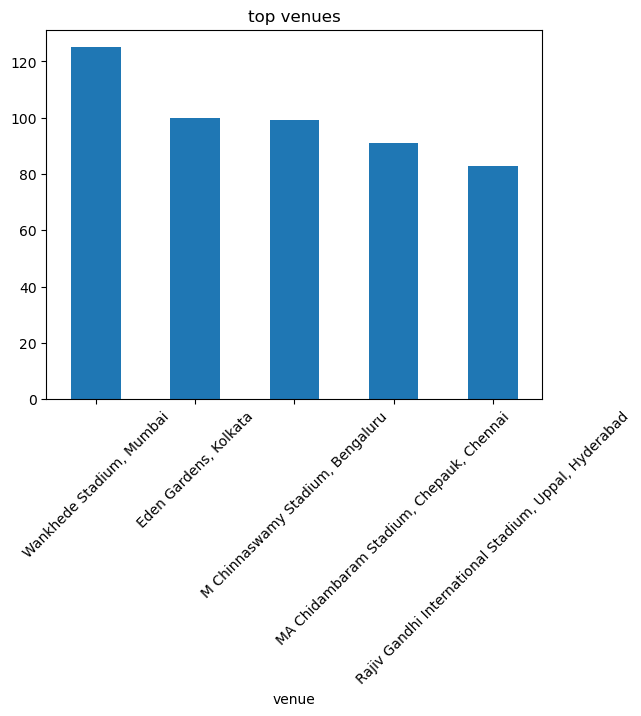

In [14]:
df['venue'].value_counts().head(5).plot(kind='bar')
plt.title('top venues')
plt.xticks(rotation=45)
plt.show()


In [ ]:
3. These 5 venues are the most popular cricket grounds.

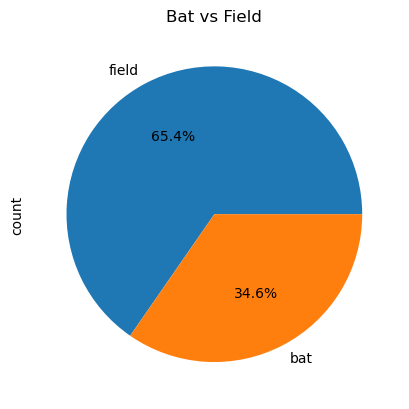

In [21]:
# bat vs field
df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Bat vs Field')
plt.show()

In [ ]:
4. Team tends to elect field more than bat after winning toss.

In [24]:
# wins by runs or wickets
df['win_outcome'].value_counts()

win_outcome
6 wickets    127
7 wickets    122
5 wickets    102
8 wickets     87
4 wickets     62
            ... 
76 runs        1
53 runs        1
105 runs       1
66 runs        1
110 runs       1
Name: count, Length: 111, dtype: int64

In [25]:
df['win_type']=df['win_outcome'].apply(lambda x:'runs' if 'runs' in str(x) else ('wickets' if 'wickets' in str(x) else 'other'))

In [26]:
df['win_type'].value_counts()

win_type
wickets    615
runs       531
other       23
Name: count, dtype: int64

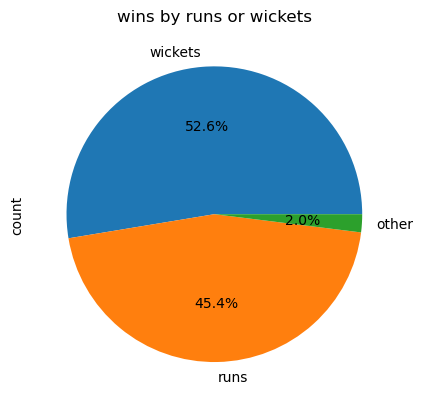

In [28]:
df['win_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('wins by runs or wickets')
plt.show()

5. This indicates that chasing teams have a higher success rate.